Number of concepts: 10


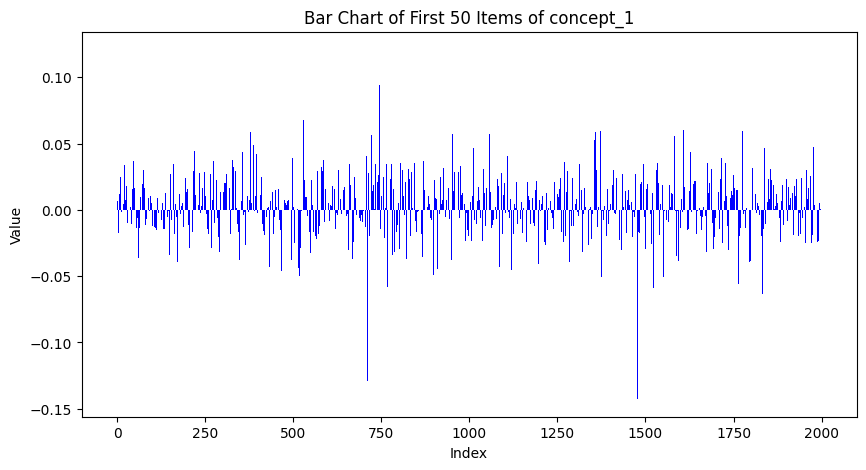

In [5]:
import torch
feature_path = "/mnt/abka03/concept_extraction_result/gemma3n/MCoX/SNMF/dtd_snmf_sparce/train/concept/redefine_activations_text_grounding_combined_concept_gl_regrounded.pth"
data = torch.load(feature_path, map_location="cpu")

hidden_states = data["concepts"]
print(f"Number of concepts: {len(hidden_states)}")
concept_1 = hidden_states[0]
import matplotlib.pyplot as plt

# Select the first 50 items of concept_1
indices = list(range(2000))
values = concept_1[:2000].numpy()

# Create a bar chart
plt.figure(figsize=(10, 5))
plt.bar(indices, values, color='blue')
plt.xlabel("Index")
plt.ylabel("Value")
plt.title("Bar Chart of First 50 Items of concept_1")
plt.show()

Number of concepts: 27


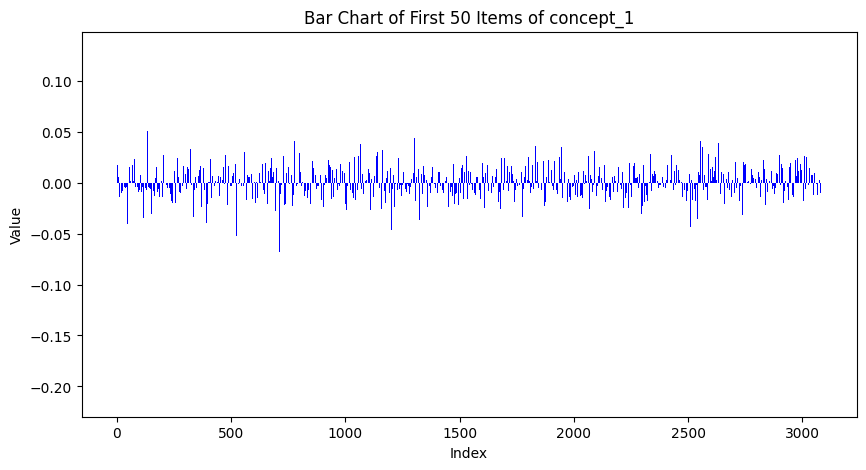

In [7]:
import torch
feature_path = "/mnt/abka03/concept_extraction_result/MCoX/SNMF/layer_norm_imagenet32/train/concept/redefine_activations_text_grounding_combined_concept_gl_regrounded.pth"
data = torch.load(feature_path, map_location="cpu")

hidden_states = data["concepts"]
print(f"Number of concepts: {len(hidden_states)}")
concept_1 = hidden_states[20]
import matplotlib.pyplot as plt

# Select the first 50 items of concept_1
indices = list(range(3084))
values = concept_1[:3084].numpy()

# Create a bar chart
plt.figure(figsize=(10, 5))
plt.bar(indices, values, color='blue')
plt.xlabel("Index")
plt.ylabel("Value")
plt.title("Bar Chart of First 50 Items of concept_1")
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def normalize(v):
    return v / np.linalg.norm(v)

# Feature vectors (unit)
f_dog = normalize(np.array([2, 3]))
f_cat = normalize(np.array([-1, -2]))

# Example activation vectors
activations = [
    np.array([1.22667242, 0.87619458]),
    np.array([-1.3123357, -0.78740142]),
    np.array([1.32380284, -0.7942817]),
    np.array([-0.67514286, -1.35028572]),
]

fig, axs = plt.subplots(2, 2, figsize=(14, 12))
axs = axs.flatten()

for i, (ax, act) in enumerate(zip(axs, activations)):
    # Projections (scalar)
    alpha_dog = np.dot(act, f_dog)
    alpha_cat = np.dot(act, f_cat)

    print(f"Activation {i+1}: alpha_dog = {alpha_dog:.3f}, alpha_cat = {alpha_cat:.3f}")

    # Projection vectors
    proj_dog = alpha_dog * f_dog
    proj_cat = alpha_cat * f_cat
    proj_sum = proj_dog + proj_cat

    origin = np.zeros(2)

    # Plot feature vectors
    ax.quiver(*origin, *f_dog, color='blue', scale_units='xy', scale=1, width=0.007, label='Feature: Dog (unit)')
    ax.quiver(*origin, *f_cat, color='green', scale_units='xy', scale=1, width=0.007, label='Feature: Cat (unit)')

    # Plot activation vector
    ax.quiver(*origin, *act, color='red', width=0.01, scale_units='xy', scale=1, label='Activation')

    # Plot projections - positive and negative differently styled
    # Dog projection
    if alpha_dog >= 0:
        ax.quiver(*origin, *proj_dog, color='cyan', width=0.007, scale_units='xy', scale=1, label='Projection on Dog (+)')
    else:
        ax.quiver(*origin, *proj_dog, color='cyan', alpha=0.5, width=0.007, scale_units='xy', scale=1, label='Projection on Dog (-)')


    # Cat projection (start at tip of proj_dog)
    if alpha_cat >= 0:
        ax.quiver(*proj_dog, *proj_cat, color='purple', width=0.007, scale_units='xy', scale=1, label='Projection on Cat (+)')
    else:
        ax.quiver(*proj_dog, *proj_cat, color='purple', alpha=0.5, width=0.007, scale_units='xy', scale=1, label='Projection on Cat (-)')


    # Sum of projections (reconstructed vector)
    ax.quiver(*origin, *proj_sum, color='orange', width=0.007, scale_units='xy', scale=1, label='Sum of Projections')

    # Annotations
    ax.text(*(f_dog + 0.1), 'f_dog', color='blue', fontsize=10)
    ax.text(*(f_cat + 0.1), 'f_cat', color='green', fontsize=10)
    ax.text(*(act + 0.15), f'Activation {i+1}', color='red', fontsize=10)
    ax.text(*(proj_sum + 0.15), 'Reconstruction', color='orange', fontsize=10)

    # Formatting
    ax.set_xlim(-3, 4)
    ax.set_ylim(-3, 4)
    ax.set_aspect('equal', 'box')
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.axhline(0, color='black', linewidth=0.5)
    ax.axvline(0, color='black', linewidth=0.5)
    ax.set_xlabel('Feature dimension 1')
    ax.set_ylabel('Feature dimension 2')
    ax.set_title(f'Activation Vector {i+1} Projection')

# Single legend for all subplots
handles, labels = axs[0].get_legend_handles_labels()

# Remove duplicates in legend
by_label = dict(zip(labels, handles))
fig.legend(by_label.values(), by_label.keys(), loc='upper center', ncol=4, fontsize=12)

plt.suptitle('Projection of Activation Vectors onto Feature Vectors (with signed dot products)', fontsize=16, y=0.95)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()


Activation 1: alpha_dog = 1.409, alpha_cat = -1.332
Activation 2: alpha_dog = -1.383, alpha_cat = 1.291
Activation 3: alpha_dog = 0.073, alpha_cat = 0.118
Activation 4: alpha_dog = -1.498, alpha_cat = 1.510


ValueError: At least one value in the dash list must be positive

<Figure size 1400x1200 with 4 Axes>

In [47]:
import torch
import torch.nn.functional as F
embeddings_path = torch.load("/mnt/abka03/concept_extraction_result/CoX/SNMF/cifar100/val/features/combined_features.pth")
embeddings = torch.stack([hid["model.norm"][0][0] for hid in embeddings_path["hidden_states"]])

feature_path = torch.load("/mnt/abka03/concept_extraction_result/CoX/SNMF/cifar100/train/concept/decompose_activations_text_grounding_image_grounding_token_embeddings_cifar100.pth")

features = feature_path["concepts"]
features = features.to(dtype=torch.float32)
embeddings = embeddings.to(dtype=torch.float32)

features_norm = F.normalize(features, dim=1)      # (20, 2000)
activations_norm = F.normalize(embeddings, dim=1)  # (100, 2000)

# Compute cosine similarity: (100, 20)
similarity = torch.matmul(activations_norm, features_norm.T)

# Get indices of top-1 most similar feature vector for each activation
top_feature_indices = similarity.argmax(dim=1)  # shape: (100,)

# Select the most similar feature vector for each activation
activations = features[top_feature_indices]  # shape: (100, 2000)


In [48]:
import numpy as np

def cosine_similarity_matrix(embeddings):
    """
    Compute pairwise cosine similarity matrix for embeddings.
    embeddings: (N, d) numpy array
    returns: (N, N) similarity matrix with values in [-1, 1]
    """
    norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
    normalized = embeddings / (norms + 1e-10)  # avoid div by zero
    return normalized @ normalized.T  # cosine similarity matrix

def min_max_normalize(arr):
    """Min-max normalize a 1D array to [0,1]."""
    min_val = arr.min()
    max_val = arr.max()
    if max_val == min_val:
        return np.zeros_like(arr)
    return (arr - min_val) / (max_val - min_val)

def compute_monoscore(X, embeddings):
    """
    Compute MonoSemanticity score per neuron.
    
    X: (N, omega) activations matrix
    embeddings: (N, d) embeddings from f(x)
    
    Returns:
      MS_scores: (omega,) array of monoscores for each neuron
    """
    N, omega = X.shape

    # 1. Compute pairwise similarity matrix S (N x N)
    S = cosine_similarity_matrix(embeddings)
    MS_scores = np.zeros(omega)
    for k in range(omega):
        # 2. Get activations for neuron k
        ak = X[:, k]
        # 3. Normalize activations to [0,1]
        ak_norm = min_max_normalize(ak)

        # 4. Compute relevance matrix R = ak_norm_n * ak_norm_m (outer product)
        R = np.outer(ak_norm, ak_norm)

        # 5. Exclude diagonal pairs (n == m) by zeroing them
        np.fill_diagonal(R, 0)

        # 6. Compute weighted average similarity for neuron k
        total_weight = R.sum()
        if total_weight == 0:
            MS_scores[k] = 0  # no strong activations
        else:
            MS_scores[k] = (R * S).sum() / total_weight

    return MS_scores
import numpy as np

# Assuming features_path["concepts"] exists and contains the data

# Convert both to numpy arrays
activations_np = activations.detach().cpu().numpy()
embeddings_np = embeddings.detach().cpu().numpy()

# Call your function
scores = compute_monoscore(activations_np, embeddings_np)

print( np.sort(scores) )

[0.48338985 0.48375201 0.48396188 ... 0.74665159 0.75717115 0.77861518]
